# IA Défenseur Adaptatif : Stratégies Mixtes pour la Sécurité Face aux Attaques Évolutives

## Objectif
Développer un système d'IA qui apprend à adapter sa stratégie de défense face à un attaquant dans un jeu répétitif, basé sur le Q-learning et la théorie des jeux.

## 1. Imports et Configuration

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from typing import Tuple, Dict, List
import warnings
warnings.filterwarnings('ignore')

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Définition du Jeu et Matrice de Récompenses

In [20]:
class GameEnvironment:
    """Jeu répétitif Défenseur vs Hacker avec coûts explicites"""
    
    def __init__(self):
        # Actions possibles
        self.defender_actions = ['Simple', 'Complexe', '2FA']
        self.hacker_actions = ['Brute', 'Dictionnaire', 'Phishing']
        
        # Indices
        self.D = {action: i for i, action in enumerate(self.defender_actions)}
        self.H = {action: i for i, action in enumerate(self.hacker_actions)}
        
        # ============================================================
        # DEFENDER: Efficacité de défense (1-10 scale)
        # ============================================================
        # vs Brute, Dictionnaire, Phishing
        self.defense_effectiveness = np.array([
            [9, 5, 2],      # Simple: très efficace contre Brute
            [6, 8, 5],      # Complexe: équilibré
            [4, 6, 10]      # 2FA: excellent contre Phishing
        ], dtype=float)
        
        # Coûts de défense pour le défenseur (1-10 scale)
        self.defense_costs = np.array([
            [1, 1, 1],      # Simple: coût bas (toujours 1)
            [3, 3, 3],      # Complexe: coût moyen (toujours 3)
            [5, 5, 5]       # 2FA: coût haut (toujours 5)
        ], dtype=float)
        
        # Récompense = Efficacité - Coût (sécurité avec économie)
        self.payoff_matrix_defender = self.defense_effectiveness - self.defense_costs
        
        # ============================================================
        # HACKER: Efficacité d'attaque (1-10 scale)
        # ============================================================
        # vs Simple, Complexe, 2FA
        self.attack_effectiveness = np.array([
            [9, 6, 4],      # Brute: très efficace contre Simple
            [5, 8, 6],      # Dictionnaire: équilibré
            [2, 5, 10]      # Phishing: excellent contre 2FA
        ], dtype=float)
        
        # Coûts d'attaque pour le hacker (1-10 scale)
        self.attack_costs = np.array([
            [2, 2, 2],      # Brute: coût bas mais détectable
            [1, 1, 1],      # Dictionnaire: coût très bas
            [3, 3, 3]       # Phishing: coût moyen (préparation)
        ], dtype=float)
        
        # Récompense = Efficacité - Coût (hack réussi avec économie)
        self.payoff_matrix_hacker = self.attack_effectiveness - self.attack_costs
        
        # Add small noise for realism
        self.payoff_matrix_hacker = self.payoff_matrix_hacker + np.random.normal(0, 0.05, (3, 3))
        
    def get_reward(self, defender_action: str, hacker_action: str) -> Tuple[float, float]:
        """Retourne les récompenses pour le défenseur et le hacker"""
        d_idx = self.D[defender_action]
        h_idx = self.H[hacker_action]
        
        defender_reward = self.payoff_matrix_defender[d_idx, h_idx]
        hacker_reward = self.payoff_matrix_hacker[d_idx, h_idx]
        
        return defender_reward, hacker_reward
    
    def display_payoff_matrices(self):
        """Affiche les matrices de récompenses avec décomposition coût/efficacité"""
        print("\n" + "="*70)
        print("DEFENDER ANALYSIS: Efficacité - Coût = Récompense")
        print("="*70)
        
        print("\nMatrice d'efficacité de défense:")
        df_eff = pd.DataFrame(
            self.defense_effectiveness,
            index=self.defender_actions,
            columns=self.hacker_actions
        )
        print(df_eff)
        
        print("\nMatrice de coûts de défense:")
        df_cost = pd.DataFrame(
            self.defense_costs,
            index=self.defender_actions,
            columns=self.hacker_actions
        )
        print(df_cost)
        
        print("\n✓ Matrice de récompenses du Défenseur (Efficacité - Coûts):")
        df_def = pd.DataFrame(
            self.payoff_matrix_defender,
            index=self.defender_actions,
            columns=self.hacker_actions
        )
        print(df_def)
        
        print("\n" + "="*70)
        print("HACKER ANALYSIS: Efficacité - Coûts = Récompense")
        print("="*70)
        
        print("\nMatrice d'efficacité d'attaque:")
        df_att_eff = pd.DataFrame(
            self.attack_effectiveness,
            index=self.hacker_actions,
            columns=self.defender_actions
        )
        print(df_att_eff)
        
        print("\nMatrice de coûts d'attaque:")
        df_att_cost = pd.DataFrame(
            self.attack_costs,
            index=self.hacker_actions,
            columns=self.defender_actions
        )
        print(df_att_cost)
        
        print("\n✓ Matrice de récompenses du Hacker (Efficacité - Coûts):")
        df_hack = pd.DataFrame(
            self.payoff_matrix_hacker,
            index=self.hacker_actions,
            columns=self.defender_actions
        )
        print(df_hack)

# Initialisation du jeu
game = GameEnvironment()
game.display_payoff_matrices()


DEFENDER ANALYSIS: Efficacité - Coût = Récompense

Matrice d'efficacité de défense:
          Brute  Dictionnaire  Phishing
Simple      9.0           5.0       2.0
Complexe    6.0           8.0       5.0
2FA         4.0           6.0      10.0

Matrice de coûts de défense:
          Brute  Dictionnaire  Phishing
Simple      1.0           1.0       1.0
Complexe    3.0           3.0       3.0
2FA         5.0           5.0       5.0

✓ Matrice de récompenses du Défenseur (Efficacité - Coûts):
          Brute  Dictionnaire  Phishing
Simple      8.0           4.0       1.0
Complexe    3.0           5.0       2.0
2FA        -1.0           1.0       5.0

HACKER ANALYSIS: Efficacité - Coûts = Récompense

Matrice d'efficacité d'attaque:
              Simple  Complexe   2FA
Brute            9.0       6.0   4.0
Dictionnaire     5.0       8.0   6.0
Phishing         2.0       5.0  10.0

Matrice de coûts d'attaque:
              Simple  Complexe  2FA
Brute            2.0       2.0  2.0
Dictionnaire

## 3. Q-Learning pour le Défenseur

In [21]:
class QLearningDefender:
    """Défenseur utilisant Q-learning avec mémoire courte (état = dernière attaque)"""
    
    def __init__(self, game: GameEnvironment, learning_rate=0.1, discount_factor=0.9, epsilon=0.1):
        self.game = game
        self.alpha = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        
        # Q-table: Q[state][action] où state = dernière action du hacker
        # state = None au début, puis state = dernière action hacker
        self.q_values = defaultdict(lambda: np.zeros(len(game.defender_actions)))
        self.action_counts = defaultdict(lambda: np.zeros(len(game.defender_actions)))
        
        # Historique pour analyse
        self.history = {
            'actions': [],
            'rewards': [],
            'q_values': [],
            'strategies': []
        }
    
    def select_action(self, hacker_last_action=None, epsilon=None) -> str:
        """Sélectionne une action avec epsilon-greedy"""
        if epsilon is None:
            epsilon = self.epsilon
            
        state = hacker_last_action if hacker_last_action else 'initial'
        
        if np.random.rand() < epsilon:
            # Exploration
            action_idx = np.random.randint(0, len(self.game.defender_actions))
        else:
            # Exploitation
            q_vals = self.q_values[state]
            action_idx = np.argmax(q_vals)
        
        return self.game.defender_actions[action_idx]
    
    def update_q_values(self, hacker_last_action, defender_action: str, reward: float, next_hacker_action: str):
        """Mise à jour Q-learning"""
        state = hacker_last_action if hacker_last_action else 'initial'
        next_state = next_hacker_action if next_hacker_action else 'initial'
        
        action_idx = self.game.D[defender_action]
        
        # Q(s,a) = Q(s,a) + α[r + γ max Q(s',a') - Q(s,a)]
        current_q = self.q_values[state][action_idx]
        max_next_q = np.max(self.q_values[next_state])
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        
        self.q_values[state][action_idx] = new_q
        self.action_counts[state][action_idx] += 1
    
    def get_strategy(self, state=None, temperature=1.0) -> np.ndarray:
        """Retourne une stratégie mixte via softmax"""
        state = state if state else 'initial'
        q_vals = self.q_values[state]
        
        # Softmax: π(a|s) = exp(Q(s,a)/T) / Σ exp(Q(s,a')/T)
        exp_q = np.exp(q_vals / temperature)
        strategy = exp_q / np.sum(exp_q)
        
        return strategy
    
    def record_step(self, action: str, reward: float):
        """Enregistre une étape pour l'analyse"""
        self.history['actions'].append(action)
        self.history['rewards'].append(reward)
        self.history['q_values'].append(dict(self.q_values))
        strategy = self.get_strategy()
        self.history['strategies'].append(strategy)

# Initialisation du défenseur
defender = QLearningDefender(game, learning_rate=0.15, epsilon=0.2)

## 4. Modèles de Hacker

In [ ]:
class Hacker:
    """Classe de base pour les hackers"""
    
    def __init__(self, game: GameEnvironment):
        self.game = game
        self.action_history = []
    
    def select_action(self) -> str:
        raise NotImplementedError

class RandomHacker(Hacker):
    """Hacker qui choisit aléatoirement"""
    
    def select_action(self) -> str:
        return np.random.choice(self.game.hacker_actions)

class AdaptiveHacker(Hacker):
    """
    Bounded-Rational Attacker using Empirical Best Response.
    
    Model: Approximates realistic attackers that:
    - React to attack OUTCOMES (success/failure), not just observed actions
    - Use outcome-based best response to refine strategy
    - Learn via Q-learning which attacks work best against each defense
    - Explore via softmax (not pure exploitation)
    - Do NOT solve game theoretically
    
    Key improvement: State = (defender_action, last_attack_success)
    This creates meaningful adaptation based on actual effectiveness.
    """
    
    def __init__(self, game: GameEnvironment, learning_rate=0.1):
        super().__init__(game)
        self.alpha = learning_rate
        # Q-table: indexed by (defender_action, attack_outcome) state
        # outcome: 'success' if reward > 0, 'failure' if reward <= 0
        self.q_values = defaultdict(lambda: np.zeros(len(game.hacker_actions)))
        self.action_counts = defaultdict(lambda: np.zeros(len(game.hacker_actions)))
        self.last_attack_success = None  # Track if last attack was effective
    
    def select_action(self, defender_action=None, last_outcome=None) -> str:
        """Sélectionne l'action basée sur les résultats observés"""
        # State = (what defender did, did last attack work?)
        if defender_action and last_outcome is not None:
            outcome_label = 'success' if last_outcome > 0 else 'failure'
            state = (defender_action, outcome_label)
        else:
            state = ('initial', 'none')
        
        q_vals = self.q_values[state]
        
        # Softmax pour exploration/exploitation
        temperature = 1.0
        exp_q = np.exp(q_vals / temperature)
        probabilities = exp_q / np.sum(exp_q)
        
        action_idx = np.random.choice(len(self.game.hacker_actions), p=probabilities)
        return self.game.hacker_actions[action_idx]
    
    def update_q_values(self, defender_action, hacker_action: str, reward: float, next_defender_action: str):
        """Mise à jour Q-learning basée sur les résultats"""
        # Current state = (what defender did, success of this attack)
        outcome_label = 'success' if reward > 0 else 'failure'
        state = (defender_action, outcome_label) if defender_action else ('initial', 'none')
        
        # Next state = (next defender action, assume neutral until update)
        next_state = (next_defender_action, 'none') if next_defender_action else ('initial', 'none')
        
        action_idx = self.game.H[hacker_action]
        
        # Q-learning update: learn which attacks work best in each situation
        current_q = self.q_values[state][action_idx]
        max_next_q = np.max(self.q_values[next_state])
        new_q = current_q + self.alpha * (reward + 0.9 * max_next_q - current_q)
        
        self.q_values[state][action_idx] = new_q
        self.action_counts[state][action_idx] += 1
        self.last_attack_success = reward
    
    def get_strategy(self, state=None, temperature=1.0) -> np.ndarray:
        """Retourne une stratégie mixte via softmax"""
        if state is None:
            state = ('initial', 'none')
        
        q_vals = self.q_values[state]
        
        # Softmax: π(a|s) = exp(Q(s,a)/T) / Σ exp(Q(s,a')/T)
        exp_q = np.exp(q_vals / temperature)
        strategy = exp_q / np.sum(exp_q)
        
        return strategy

# Initialisation des hackers
random_hacker = RandomHacker(game)
adaptive_hacker = AdaptiveHacker(game, learning_rate=0.15)

## 5. Boucle d'Apprentissage

In [ ]:
def train_game(defender, hacker, game, num_episodes=1000, hacker_type='adaptive'):
    """Boucle d'apprentissage principal"""
    
    defender_rewards = []
    hacker_rewards = []
    defender_actions_history = []
    hacker_actions_history = []
    
    for episode in range(num_episodes):
        # Choix simultanés
        if hacker_type == 'random':
            hacker_action = hacker.select_action()
        else:  # adaptive
            # Hacker adapts based on last defender action and whether last attack succeeded
            defender_last_action = defender.history['actions'][-1] if defender.history['actions'] else None
            last_hacker_reward = hacker_rewards[-1] if hacker_rewards else None
            hacker_action = hacker.select_action(defender_last_action, last_hacker_reward)
        
        defender_action = defender.select_action(
            hacker_last_action=hacker.action_history[-1] if hacker.action_history else None
        )
        
        # Calcul des récompenses
        d_reward, h_reward = game.get_reward(defender_action, hacker_action)
        
        # Mise à jour Q-values du défenseur
        next_hacker_action = hacker_action
        defender.update_q_values(
            hacker_last_action=hacker.action_history[-1] if hacker.action_history else None,
            defender_action=defender_action,
            reward=d_reward,
            next_hacker_action=next_hacker_action
        )
        
        # Mise à jour Q-values du hacker adaptatif
        if hacker_type == 'adaptive':
            hacker.update_q_values(
                defender_action=defender.history['actions'][-1] if defender.history['actions'] else None,
                hacker_action=hacker_action,
                reward=h_reward,
                next_defender_action=defender_action
            )
        
        # Enregistrement
        defender.record_step(defender_action, d_reward)
        hacker.action_history.append(hacker_action)
        defender_rewards.append(d_reward)
        hacker_rewards.append(h_reward)
        defender_actions_history.append(defender_action)
        hacker_actions_history.append(hacker_action)
    
    return {
        'defender_rewards': defender_rewards,
        'hacker_rewards': hacker_rewards,
        'defender_actions': defender_actions_history,
        'hacker_actions': hacker_actions_history
    }

# Entraînement contre hacker adaptatif
print("Entraînement du défenseur contre un hacker adaptatif...")
results = train_game(defender, adaptive_hacker, game, num_episodes=5000, hacker_type='adaptive')
print(f"Nombre d'épisodes: {len(results['defender_rewards'])}")
print(f"Récompense moyenne défenseur (derniers 100 épisodes): {np.mean(results['defender_rewards'][-100:]):.2f}")

Entraînement du défenseur contre un hacker adaptatif...
Nombre d'épisodes: 5000
Récompense moyenne défenseur (derniers 100 épisodes): 6.20


## 6. Construction de la Stratégie Mixte


Stratégie mixte finale du Défenseur (état initial):
  Simple: 0.224
  Complexe: 0.552
  2FA: 0.224

Stratégies mixtes selon l'attaque précédente du hacker:

Après attaque 'Brute':
  Simple: 1.000
  Complexe: 0.000
  2FA: 0.000

Après attaque 'Dictionnaire':
  Simple: 1.000
  Complexe: 0.000
  2FA: 0.000

Après attaque 'Phishing':
  Simple: 1.000
  Complexe: 0.000
  2FA: 0.000


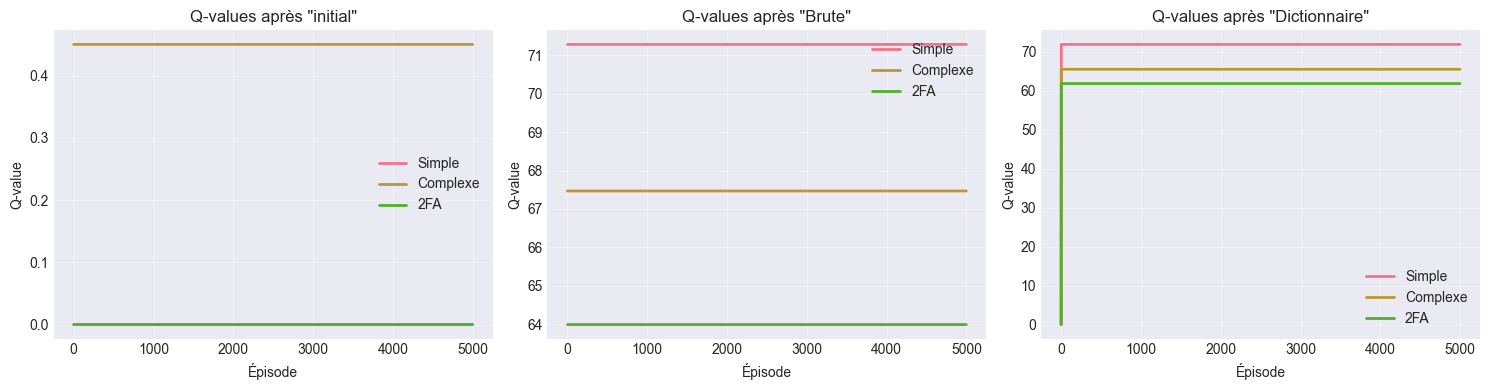

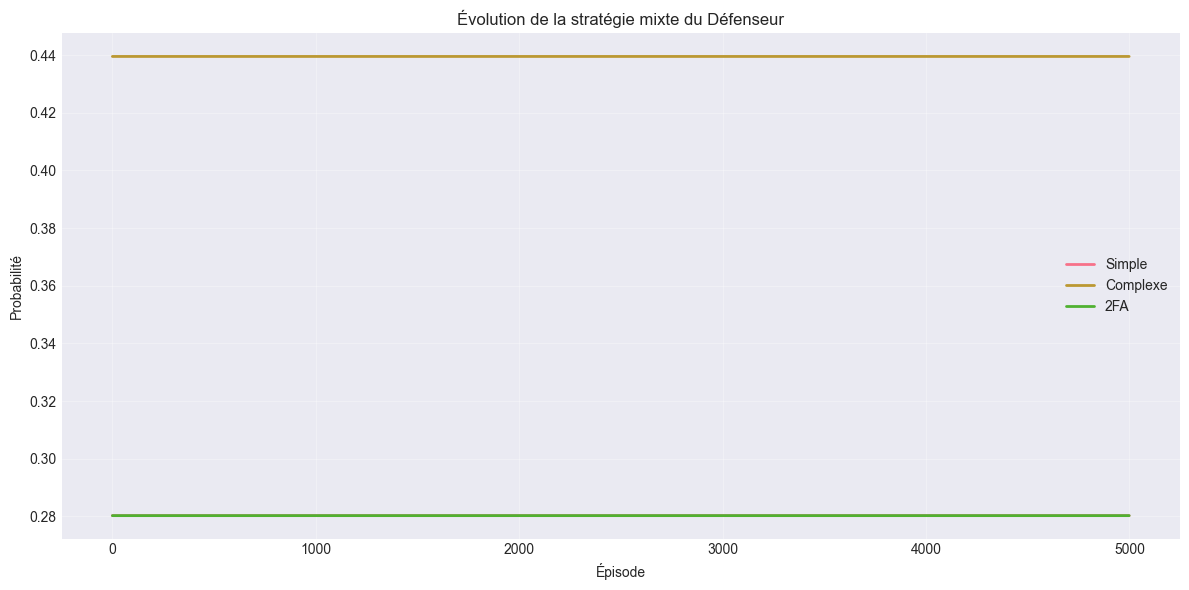

In [24]:
# Stratégies finales
initial_strategy = defender.get_strategy('initial', temperature=0.5)
print("\nStratégie mixte finale du Défenseur (état initial):")
for action, prob in zip(game.defender_actions, initial_strategy):
    print(f"  {action}: {prob:.3f}")

# Stratégies pour chaque état (dernière attaque du hacker)
print("\nStratégies mixtes selon l'attaque précédente du hacker:")
for hacker_action in game.hacker_actions:
    strategy = defender.get_strategy(hacker_action, temperature=0.5)
    print(f"\nAprès attaque '{hacker_action}':")
    for def_action, prob in zip(game.defender_actions, strategy):
        print(f"  {def_action}: {prob:.3f}")

# Visualisation de l'évolution des Q-values (pour les 3 premiers états)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

states_to_plot = ['initial'] + game.hacker_actions[:2]  # Limiter à 3 états

for state_idx, state in enumerate(states_to_plot):
    ax = axes[state_idx]
    q_evolution = []
    
    for step_data in defender.history['q_values']:
        q_vals = step_data.get(state, np.zeros(3))
        q_evolution.append(q_vals)
    
    q_evolution = np.array(q_evolution)
    
    for action_idx, action in enumerate(game.defender_actions):
        ax.plot(q_evolution[:, action_idx], label=action, linewidth=2)
    
    ax.set_title(f'Q-values après "{state}"')
    ax.set_xlabel('Épisode')
    ax.set_ylabel('Q-value')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualisation de l'évolution des stratégies
fig, ax = plt.subplots(figsize=(12, 6))

initial_strategies = np.array(defender.history['strategies'])

for action_idx, action in enumerate(game.defender_actions):
    ax.plot(initial_strategies[:, action_idx], label=action, linewidth=2)

ax.set_title('Évolution de la stratégie mixte du Défenseur')
ax.set_xlabel('Épisode')
ax.set_ylabel('Probabilité')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Analyse de l'Équilibre

ANALYSE DE L'ÉQUILIBRE

⚠️  IMPORTANT: Convergence to a theoretical Nash equilibrium is NOT guaranteed.
We analyze EMPIRICAL stability and observed mixed strategy behavior instead.

Récompenses moyennes (derniers 200 épisodes):
  Défenseur: 6.21
  Hacker: 5.69

Entropie de la stratégie:
  Initiale: 1.074
  Finale: 1.074
  Entropie maximale (uniforme): 1.099

Variance des récompenses (derniers 500 épisodes): 8.409

Fréquence des actions du Défenseur:
  Simple: 0.869
  Complexe: 0.068
  2FA: 0.063

Meilleures paires de stratégies (Défenseur, Hacker):
  (Simple, Brute): 8.00 (fréquence: 3771)
  (2FA, Phishing): 5.00 (fréquence: 19)
  (Complexe, Dictionnaire): 5.00 (fréquence: 17)
  (Simple, Dictionnaire): 4.00 (fréquence: 300)
  (Complexe, Brute): 3.00 (fréquence: 304)


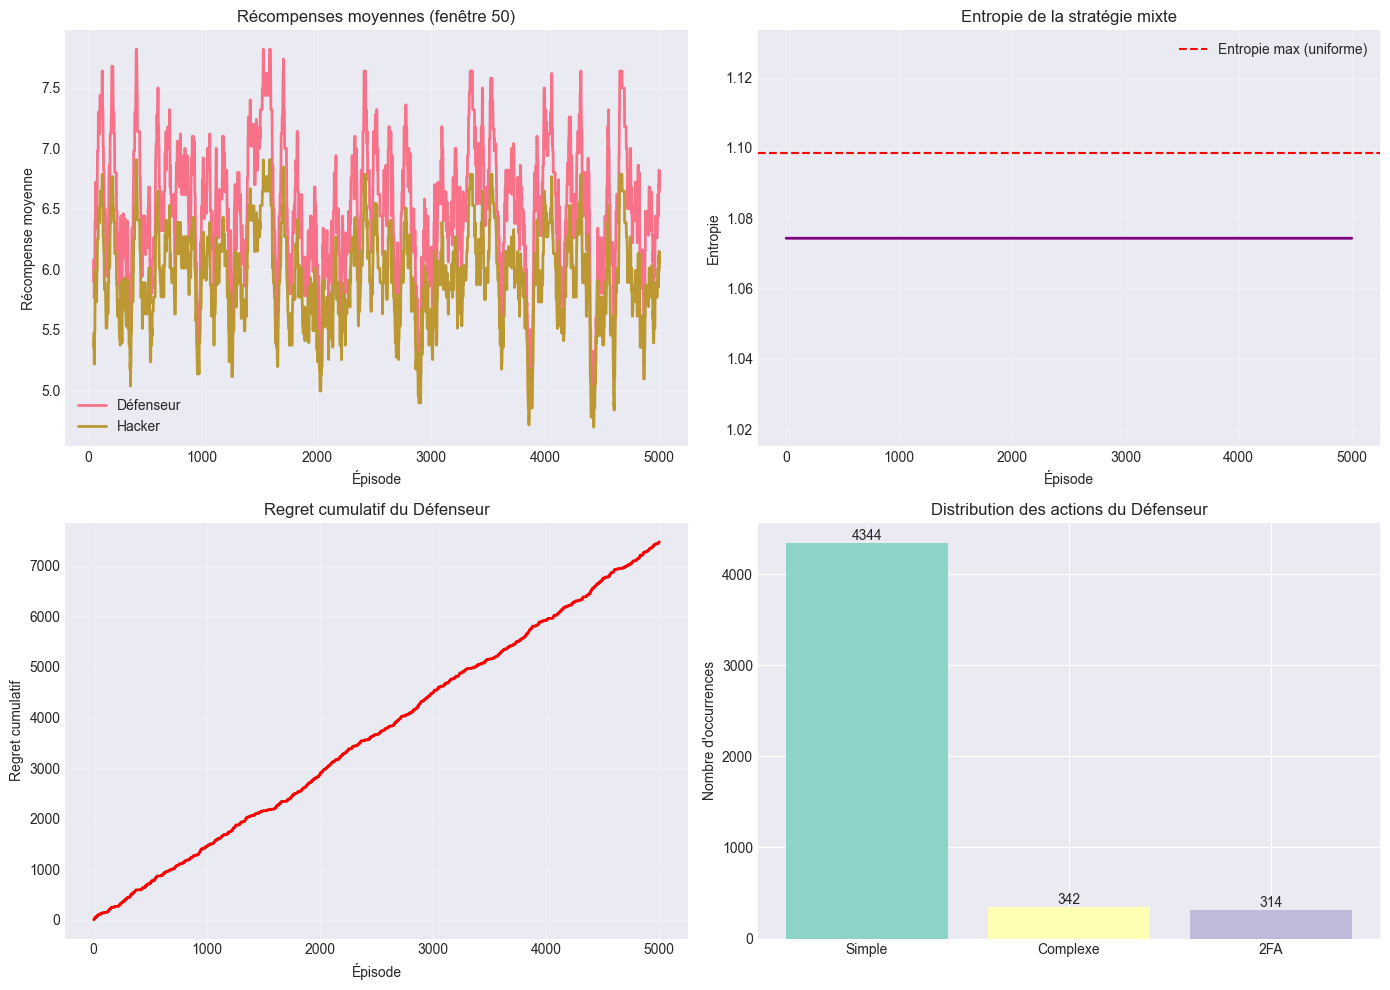

In [25]:
def calculate_entropy(strategy):
    """Calcule l'entropie Shannon de la stratégie"""
    # Éviter log(0)
    strategy = np.clip(strategy, 1e-10, 1)
    return -np.sum(strategy * np.log(strategy))

def calculate_regret(rewards, num_actions=3):
    """Calcule le regret cumulatif"""
    max_reward = np.max(game.payoff_matrix_defender.flatten())
    regrets = max_reward - np.array(rewards)
    cumulative_regret = np.cumsum(regrets)
    return cumulative_regret

# Analyse des récompenses
defender_rewards = results['defender_rewards']
hacker_rewards = results['hacker_rewards']

print("=" * 60)
print("ANALYSE DE L'ÉQUILIBRE")
print("=" * 60)
print("\n⚠️  IMPORTANT: Convergence to a theoretical Nash equilibrium is NOT guaranteed.")
print("We analyze EMPIRICAL stability and observed mixed strategy behavior instead.\n")

# Récompenses moyennes
window = 200
print(f"Récompenses moyennes (derniers {window} épisodes):")
print(f"  Défenseur: {np.mean(defender_rewards[-window:]):.2f}")
print(f"  Hacker: {np.mean(hacker_rewards[-window:]):.2f}")

# Entropie de la stratégie
entropies = [calculate_entropy(s) for s in defender.history['strategies']]
print(f"\nEntropie de la stratégie:")
print(f"  Initiale: {entropies[0]:.3f}")
print(f"  Finale: {entropies[-1]:.3f}")
print(f"  Entropie maximale (uniforme): {np.log(3):.3f}")

# Regret cumulatif
cumulative_regret = calculate_regret(defender_rewards)

# Variance des récompenses
variance_window = 500
recent_rewards = defender_rewards[-variance_window:]
print(f"\nVariance des récompenses (derniers {variance_window} épisodes): {np.var(recent_rewards):.3f}")

# Fréquence des actions
action_counts = {action: results['defender_actions'].count(action) for action in game.defender_actions}
total_actions = len(results['defender_actions'])
print(f"\nFréquence des actions du Défenseur:")
for action, count in action_counts.items():
    print(f"  {action}: {count/total_actions:.3f}")

# Paires de stratégies (Défenseur, Hacker)
pair_rewards = defaultdict(lambda: {'count': 0, 'total_reward': 0})
for d_action, h_action, reward in zip(results['defender_actions'], results['hacker_actions'], defender_rewards):
    pair = (d_action, h_action)
    pair_rewards[pair]['count'] += 1
    pair_rewards[pair]['total_reward'] += reward

print(f"\nMeilleures paires de stratégies (Défenseur, Hacker):")
sorted_pairs = sorted(pair_rewards.items(), key=lambda x: x[1]['total_reward']/max(x[1]['count'], 1), reverse=True)
for (d_action, h_action), data in sorted_pairs[:5]:
    avg_reward = data['total_reward'] / max(data['count'], 1)
    print(f"  ({d_action}, {h_action}): {avg_reward:.2f} (fréquence: {data['count']})")

# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Récompenses cumulatives
ax = axes[0, 0]
window_size = 50
defender_ma = pd.Series(defender_rewards).rolling(window_size).mean()
hacker_ma = pd.Series(hacker_rewards).rolling(window_size).mean()
ax.plot(defender_ma, label='Défenseur', linewidth=2)
ax.plot(hacker_ma, label='Hacker', linewidth=2)
ax.set_title(f'Récompenses moyennes (fenêtre {window_size})')
ax.set_xlabel('Épisode')
ax.set_ylabel('Récompense moyenne')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Entropie
ax = axes[0, 1]
ax.plot(entropies, linewidth=2, color='purple')
ax.axhline(y=np.log(3), color='r', linestyle='--', label='Entropie max (uniforme)')
ax.set_title('Entropie de la stratégie mixte')
ax.set_xlabel('Épisode')
ax.set_ylabel('Entropie')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Regret cumulatif
ax = axes[1, 0]
ax.plot(cumulative_regret, linewidth=2, color='red')
ax.set_title('Regret cumulatif du Défenseur')
ax.set_xlabel('Épisode')
ax.set_ylabel('Regret cumulatif')
ax.grid(True, alpha=0.3)

# 4. Distribution des actions
ax = axes[1, 1]
actions = list(action_counts.keys())
counts = list(action_counts.values())
colors = plt.cm.Set3(range(len(actions)))
bars = ax.bar(actions, counts, color=colors)
ax.set_title('Distribution des actions du Défenseur')
ax.set_ylabel('Nombre d\'occurrences')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)

## 8. Comparaison avec Équilibre de Nash Théorique

APPROXIMATE EQUILIBRIUM ANALYSIS (Illustrative Comparison)

⚠️  NOTE: This assumes uniform mixed strategy as a reference point.
Results are AVERAGED across all states (initial + hacker actions).

Uniform Strategy Reference (Defender):
  Simple: 0.333
  Complexe: 0.333
  2FA: 0.333

Uniform Strategy Reference (Hacker):
  Brute: 0.333
  Dictionnaire: 0.333
  Phishing: 0.333

EMPIRICAL STRATEGY vs UNIFORM REFERENCE

Stratégie apprise:
  Simple: 0.224
  Complexe: 0.552
  2FA: 0.224

Différence avec Nash:
  Simple: -0.109
  Complexe: +0.218
  2FA: -0.109

Payoff espéré du Défenseur:
  Avec stratégie apprise: 3.184
  Avec stratégie uniforme: 3.111


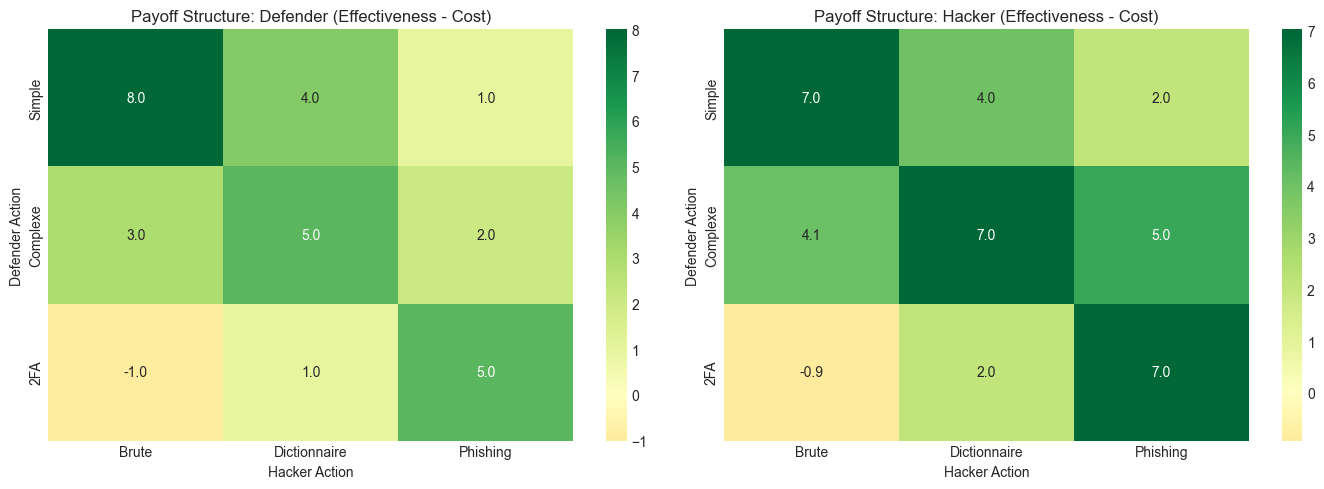

In [26]:
def find_nash_equilibrium_mixed(payoff_matrix):
    """
    Cherche un équilibre de Nash en stratégies mixtes
    Pour un jeu 3x3, on utilise une approche numérique
    """
    from scipy.optimize import linprog
    
    # Simplifié: on cherche les stratégies de support maximal
    # C'est une approximation - l'équilibre exact nécessite un solveur plus sophistiqué
    
    # Pour démonstration, on calcule les payoffs espérés
    payoff_def = game.payoff_matrix_defender
    payoff_hack = game.payoff_matrix_hacker
    
    # Stratégie uniforme comme approximation
    nash_def = np.ones(3) / 3
    nash_hack = np.ones(3) / 3
    
    return nash_def, nash_hack

# Calcul de l'équilibre théorique (approximation)
nash_defender, nash_hacker = find_nash_equilibrium_mixed(game.payoff_matrix_defender)

print("=" * 60)
print("APPROXIMATE EQUILIBRIUM ANALYSIS (Illustrative Comparison)")
print("=" * 60)
print("\n⚠️  NOTE: This assumes uniform mixed strategy as a reference point.")
print("Results are AVERAGED across all states (initial + hacker actions).\n")
print("Uniform Strategy Reference (Defender):")
for action, prob in zip(game.defender_actions, nash_defender):
    print(f"  {action}: {prob:.3f}")

print("\nUniform Strategy Reference (Hacker):")
for action, prob in zip(game.hacker_actions, nash_hacker):
    print(f"  {action}: {prob:.3f}")

# Comparaison avec la stratégie apprise
learned_strategy = defender.get_strategy('initial', temperature=0.5)

print("\n" + "=" * 60)
print("EMPIRICAL STRATEGY vs UNIFORM REFERENCE")
print("=" * 60)
print("\nStratégie apprise:")
for action, prob in zip(game.defender_actions, learned_strategy):
    print(f"  {action}: {prob:.3f}")

print("\nDifférence avec Nash:")
for action, learned, nash in zip(game.defender_actions, learned_strategy, nash_defender):
    diff = learned - nash
    print(f"  {action}: {diff:+.3f}")

# Payoff espéré avec stratégies apprise vs Nash
def expected_payoff(defender_strategy, hacker_strategy, payoff_matrix):
    """Calcule le payoff espéré"""
    return np.dot(defender_strategy, np.dot(payoff_matrix, hacker_strategy))

payoff_learned = expected_payoff(learned_strategy, nash_hacker, game.payoff_matrix_defender)
payoff_nash = expected_payoff(nash_defender, nash_hacker, game.payoff_matrix_defender)

print(f"\nPayoff espéré du Défenseur:")
print(f"  Avec stratégie apprise: {payoff_learned:.3f}")
print(f"  Avec stratégie uniforme: {payoff_nash:.3f}")

# Payoff matrices for reference (illustrative, not Nash solution)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Defender
ax = axes[0]
sns.heatmap(game.payoff_matrix_defender, 
            annot=True, fmt='.1f',
            xticklabels=game.hacker_actions,
            yticklabels=game.defender_actions,
            cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Payoff Structure: Defender (Effectiveness - Cost)')
ax.set_xlabel('Hacker Action')
ax.set_ylabel('Defender Action')

# Hacker
ax = axes[1]
sns.heatmap(game.payoff_matrix_hacker,
            annot=True, fmt='.1f',
            xticklabels=game.hacker_actions,
            yticklabels=game.defender_actions,
            cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Payoff Structure: Hacker (Effectiveness - Cost)')
ax.set_xlabel('Hacker Action')
ax.set_ylabel('Defender Action')

plt.tight_layout()
plt.show()

## 9. Expériments Comparatifs


EXPÉRIENCE 1: CONTRE HACKER ALÉATOIRE
Récompense moyenne défenseur (derniers 100 épisodes): 4.05

Stratégie mixte apprise contre hacker aléatoire:
  Simple: 0.403
  Complexe: 0.299
  2FA: 0.299


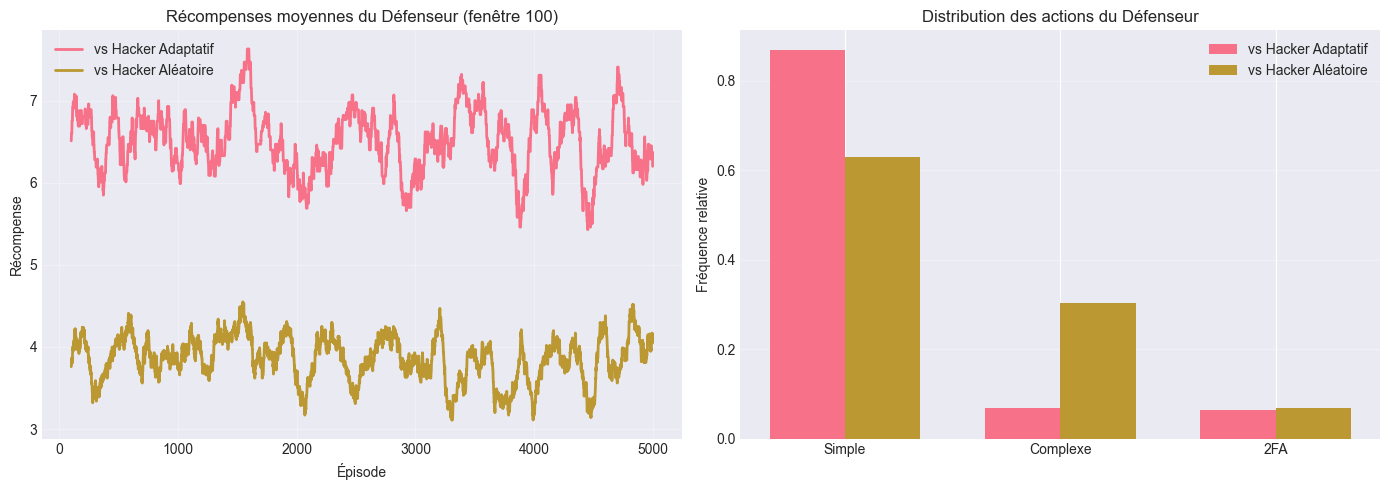


RÉSUMÉ COMPARATIF
Contre Hacker Adaptatif   - Récompense moyenne: 6.20
Contre Hacker Aléatoire   - Récompense moyenne: 4.05
Différence: 2.15


In [27]:
# Comparaison: Défenseur vs Random Hacker vs Adaptive Hacker
print("\n" + "=" * 60)
print("EXPÉRIENCE 1: CONTRE HACKER ALÉATOIRE")
print("=" * 60)

# Réinitialisation
defender_vs_random = QLearningDefender(game, learning_rate=0.15, epsilon=0.2)
random_hacker_fresh = RandomHacker(game)

results_random = train_game(defender_vs_random, random_hacker_fresh, game, 
                            num_episodes=5000, hacker_type='random')

print(f"Récompense moyenne défenseur (derniers 100 épisodes): {np.mean(results_random['defender_rewards'][-100:]):.2f}")

strategy_vs_random = defender_vs_random.get_strategy('initial', temperature=0.5)
print("\nStratégie mixte apprise contre hacker aléatoire:")
for action, prob in zip(game.defender_actions, strategy_vs_random):
    print(f"  {action}: {prob:.3f}")

# Graphique de comparaison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Récompenses
ax = axes[0]
window_size = 100
defender_ma_adaptive = pd.Series(results['defender_rewards']).rolling(window_size).mean()
defender_ma_random = pd.Series(results_random['defender_rewards']).rolling(window_size).mean()

ax.plot(defender_ma_adaptive, label='vs Hacker Adaptatif', linewidth=2)
ax.plot(defender_ma_random, label='vs Hacker Aléatoire', linewidth=2)
ax.set_title(f'Récompenses moyennes du Défenseur (fenêtre {window_size})')
ax.set_xlabel('Épisode')
ax.set_ylabel('Récompense')
ax.legend()
ax.grid(True, alpha=0.3)

# Distributions des actions
ax = axes[1]
x = np.arange(len(game.defender_actions))
width = 0.35

counts_adaptive = [results['defender_actions'].count(a) / len(results['defender_actions']) 
                   for a in game.defender_actions]
counts_random = [results_random['defender_actions'].count(a) / len(results_random['defender_actions']) 
                 for a in game.defender_actions]

ax.bar(x - width/2, counts_adaptive, width, label='vs Hacker Adaptatif')
ax.bar(x + width/2, counts_random, width, label='vs Hacker Aléatoire')
ax.set_ylabel('Fréquence relative')
ax.set_title('Distribution des actions du Défenseur')
ax.set_xticks(x)
ax.set_xticklabels(game.defender_actions)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("RÉSUMÉ COMPARATIF")
print("=" * 60)
print(f"Contre Hacker Adaptatif   - Récompense moyenne: {np.mean(results['defender_rewards'][-100:]):.2f}")
print(f"Contre Hacker Aléatoire   - Récompense moyenne: {np.mean(results_random['defender_rewards'][-100:]):.2f}")
print(f"Différence: {np.mean(results['defender_rewards'][-100:]) - np.mean(results_random['defender_rewards'][-100:]):.2f}")

## 10. Analyse d'Impact des Hyperparamètres


ANALYSE D'IMPACT: LEARNING RATE

Learning Rate = 0.05
  Récompense moyenne (derniers 100): 6.63

Learning Rate = 0.1
  Récompense moyenne (derniers 100): 5.66

Learning Rate = 0.15
  Récompense moyenne (derniers 100): 6.65

Learning Rate = 0.2
  Récompense moyenne (derniers 100): 6.34

ANALYSE D'IMPACT: EXPLORATION (EPSILON)

Epsilon = 0.1
  Récompense moyenne (derniers 100): 7.60

Epsilon = 0.2
  Récompense moyenne (derniers 100): 2.71

Epsilon = 0.3
  Récompense moyenne (derniers 100): 5.95

Epsilon = 0.4
  Récompense moyenne (derniers 100): 3.21


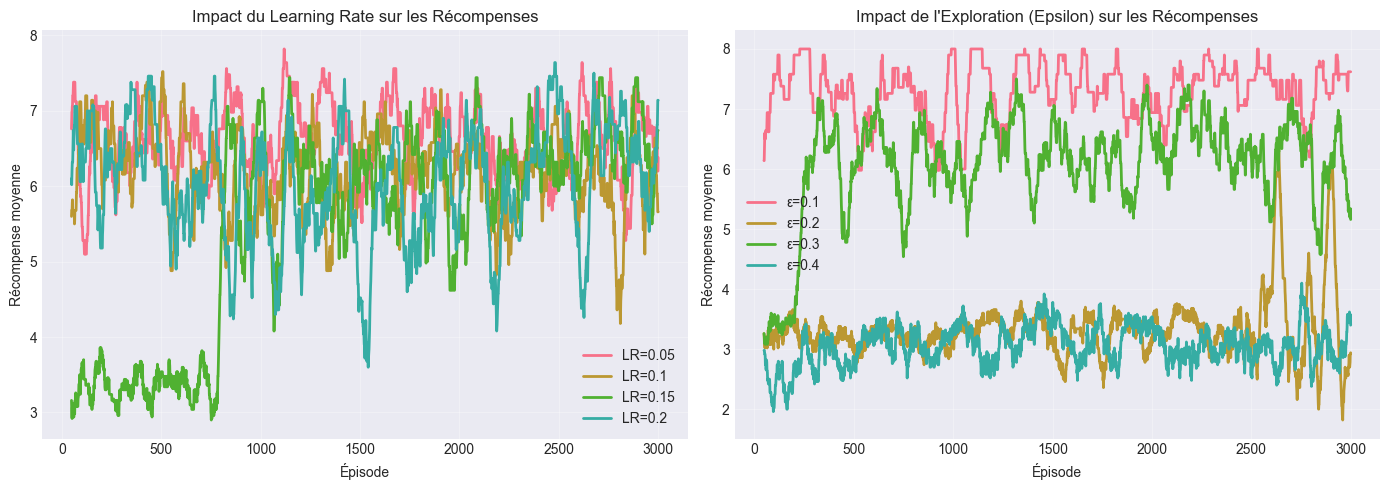

In [28]:
# Étude d'impact des hyperparamètres
learning_rates = [0.05, 0.1, 0.15, 0.2]
epsilons = [0.1, 0.2, 0.3, 0.4]

results_lr = {}
results_eps = {}

# Impact du learning rate
print("\n" + "=" * 60)
print("ANALYSE D'IMPACT: LEARNING RATE")
print("=" * 60)

for lr in learning_rates:
    print(f"\nLearning Rate = {lr}")
    defender_test = QLearningDefender(game, learning_rate=lr, epsilon=0.2)
    adaptive_hacker_test = AdaptiveHacker(game, learning_rate=0.15)
    
    results_test = train_game(defender_test, adaptive_hacker_test, game, 
                              num_episodes=3000, hacker_type='adaptive')
    results_lr[lr] = results_test
    
    avg_reward = np.mean(results_test['defender_rewards'][-100:])
    print(f"  Récompense moyenne (derniers 100): {avg_reward:.2f}")

# Impact de l'epsilon (exploration)
print("\n" + "=" * 60)
print("ANALYSE D'IMPACT: EXPLORATION (EPSILON)")
print("=" * 60)

for epsilon in epsilons:
    print(f"\nEpsilon = {epsilon}")
    defender_test = QLearningDefender(game, learning_rate=0.15, epsilon=epsilon)
    adaptive_hacker_test = AdaptiveHacker(game, learning_rate=0.15)
    
    results_test = train_game(defender_test, adaptive_hacker_test, game, 
                              num_episodes=3000, hacker_type='adaptive')
    results_eps[epsilon] = results_test
    
    avg_reward = np.mean(results_test['defender_rewards'][-100:])
    print(f"  Récompense moyenne (derniers 100): {avg_reward:.2f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning rate impact
ax = axes[0]
window_size = 50
for lr, result in results_lr.items():
    ma = pd.Series(result['defender_rewards']).rolling(window_size).mean()
    ax.plot(ma, label=f'LR={lr}', linewidth=2)

ax.set_title('Impact du Learning Rate sur les Récompenses')
ax.set_xlabel('Épisode')
ax.set_ylabel('Récompense moyenne')
ax.legend()
ax.grid(True, alpha=0.3)

# Epsilon impact
ax = axes[1]
for epsilon, result in results_eps.items():
    ma = pd.Series(result['defender_rewards']).rolling(window_size).mean()
    ax.plot(ma, label=f'ε={epsilon}', linewidth=2)

ax.set_title('Impact de l\'Exploration (Epsilon) sur les Récompenses')
ax.set_xlabel('Épisode')
ax.set_ylabel('Récompense moyenne')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Analyse Coûts vs Bénéfices (Défenseur et Hacker)


COST-BENEFIT ANALYSIS: DEFENDER


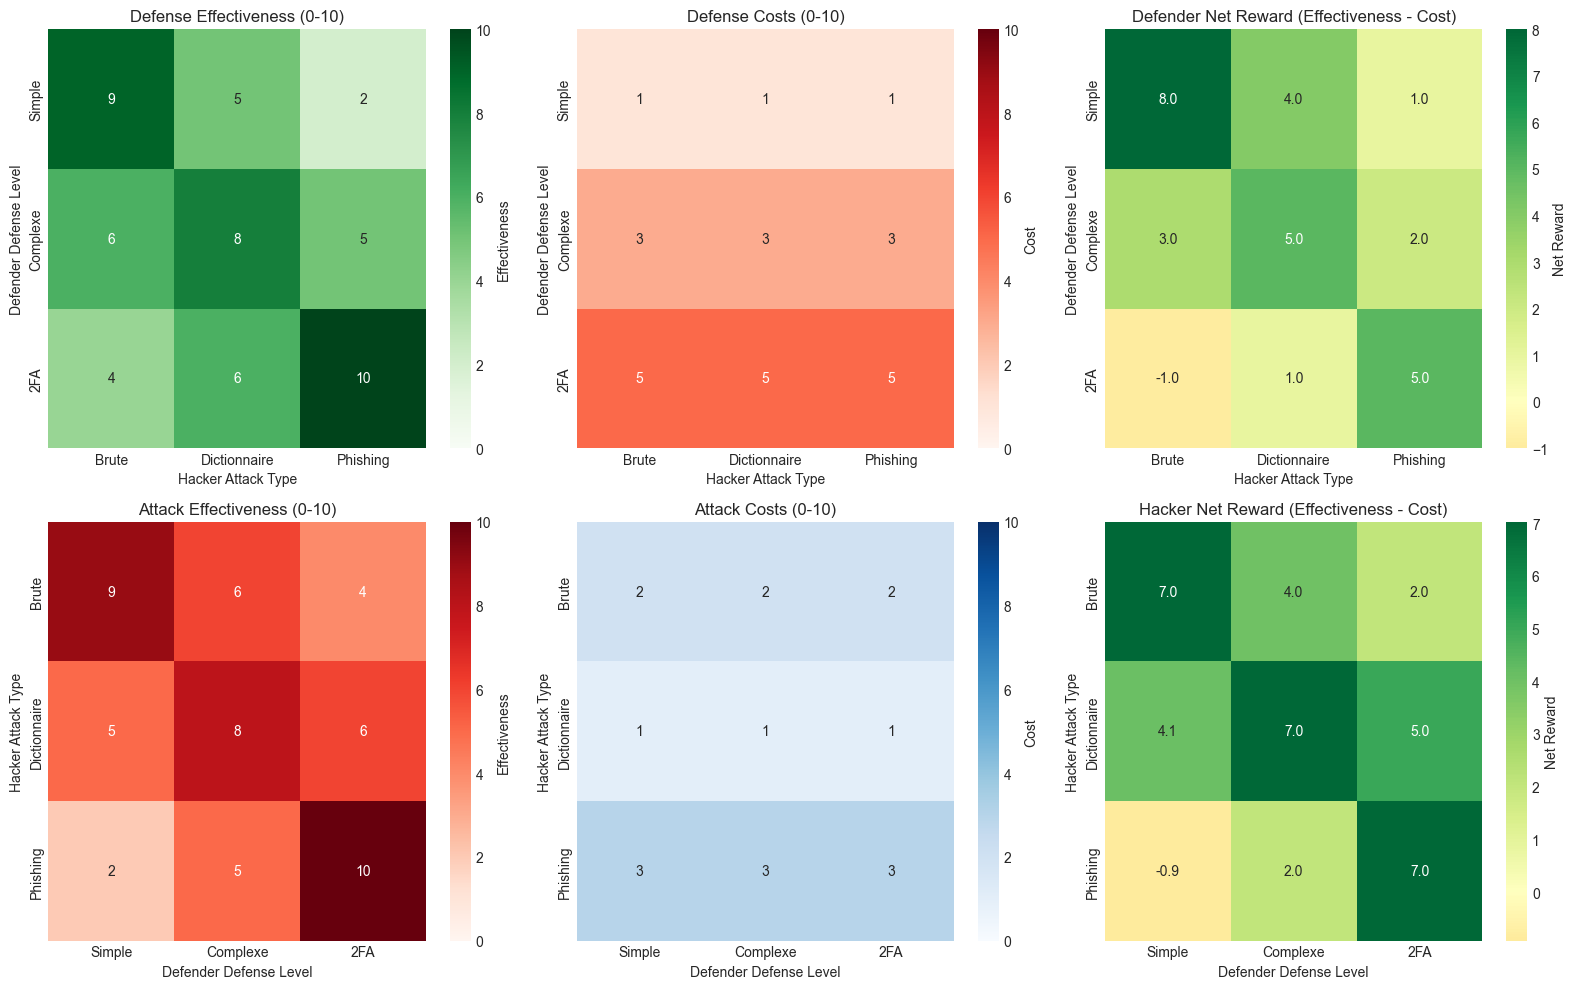


📊 DEFENDER COST-BENEFIT ANALYSIS:

Defense Strategy | Avg Effectiveness | Avg Cost | Avg Net Benefit
----------------------------------------------------------------------
Simple           |               5.3 |      1.0 |            4.3
Complexe         |               6.3 |      3.0 |            3.3
2FA              |               6.7 |      5.0 |            1.7

📊 HACKER COST-BENEFIT ANALYSIS:

Attack Strategy  | Avg Effectiveness | Avg Cost | Avg Net Benefit
----------------------------------------------------------------------
Brute            |               6.3 |      2.0 |            4.4
Dictionnaire     |               6.3 |      1.0 |            5.4
Phishing         |               5.7 |      3.0 |            2.7


In [29]:
# ============================================================
# COST-BENEFIT ANALYSIS: DEFENDER
# ============================================================

print("\n" + "="*80)
print("COST-BENEFIT ANALYSIS: DEFENDER")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Defender Effectiveness
ax = axes[0, 0]
sns.heatmap(game.defense_effectiveness, annot=True, fmt='.0f',
            xticklabels=game.hacker_actions,
            yticklabels=game.defender_actions,
            cmap='Greens', vmin=0, vmax=10, ax=ax, cbar_kws={'label': 'Effectiveness'})
ax.set_title('Defense Effectiveness (0-10)')
ax.set_xlabel('Hacker Attack Type')
ax.set_ylabel('Defender Defense Level')

# Defender Costs
ax = axes[0, 1]
sns.heatmap(game.defense_costs, annot=True, fmt='.0f',
            xticklabels=game.hacker_actions,
            yticklabels=game.defender_actions,
            cmap='Reds', vmin=0, vmax=10, ax=ax, cbar_kws={'label': 'Cost'})
ax.set_title('Defense Costs (0-10)')
ax.set_xlabel('Hacker Attack Type')
ax.set_ylabel('Defender Defense Level')

# Defender Net Reward
ax = axes[0, 2]
sns.heatmap(game.payoff_matrix_defender, annot=True, fmt='.1f',
            xticklabels=game.hacker_actions,
            yticklabels=game.defender_actions,
            cmap='RdYlGn', center=0, ax=ax, cbar_kws={'label': 'Net Reward'})
ax.set_title('Defender Net Reward (Effectiveness - Cost)')
ax.set_xlabel('Hacker Attack Type')
ax.set_ylabel('Defender Defense Level')

# ============================================================
# COST-BENEFIT ANALYSIS: HACKER
# ============================================================

# Hacker Attack Effectiveness
ax = axes[1, 0]
sns.heatmap(game.attack_effectiveness, annot=True, fmt='.0f',
            xticklabels=game.defender_actions,
            yticklabels=game.hacker_actions,
            cmap='Reds', vmin=0, vmax=10, ax=ax, cbar_kws={'label': 'Effectiveness'})
ax.set_title('Attack Effectiveness (0-10)')
ax.set_xlabel('Defender Defense Level')
ax.set_ylabel('Hacker Attack Type')

# Hacker Attack Costs
ax = axes[1, 1]
sns.heatmap(game.attack_costs, annot=True, fmt='.0f',
            xticklabels=game.defender_actions,
            yticklabels=game.hacker_actions,
            cmap='Blues', vmin=0, vmax=10, ax=ax, cbar_kws={'label': 'Cost'})
ax.set_title('Attack Costs (0-10)')
ax.set_xlabel('Defender Defense Level')
ax.set_ylabel('Hacker Attack Type')

# Hacker Net Reward
ax = axes[1, 2]
sns.heatmap(game.payoff_matrix_hacker, annot=True, fmt='.1f',
            xticklabels=game.defender_actions,
            yticklabels=game.hacker_actions,
            cmap='RdYlGn', center=0, ax=ax, cbar_kws={'label': 'Net Reward'})
ax.set_title('Hacker Net Reward (Effectiveness - Cost)')
ax.set_xlabel('Defender Defense Level')
ax.set_ylabel('Hacker Attack Type')

plt.tight_layout()
plt.show()

# Detailed cost-benefit analysis
print("\n📊 DEFENDER COST-BENEFIT ANALYSIS:\n")
print("Defense Strategy | Avg Effectiveness | Avg Cost | Avg Net Benefit")
print("-" * 70)
for i, defense in enumerate(game.defender_actions):
    avg_eff = np.mean(game.defense_effectiveness[i, :])
    avg_cost = np.mean(game.defense_costs[i, :])
    avg_net = np.mean(game.payoff_matrix_defender[i, :])
    print(f"{defense:16} | {avg_eff:17.1f} | {avg_cost:8.1f} | {avg_net:14.1f}")

print("\n📊 HACKER COST-BENEFIT ANALYSIS:\n")
print("Attack Strategy  | Avg Effectiveness | Avg Cost | Avg Net Benefit")
print("-" * 70)
for i, attack in enumerate(game.hacker_actions):
    avg_eff = np.mean(game.attack_effectiveness[i, :])
    avg_cost = np.mean(game.attack_costs[i, :])
    avg_net = np.mean(game.payoff_matrix_hacker[i, :])
    print(f"{attack:16} | {avg_eff:17.1f} | {avg_cost:8.1f} | {avg_net:14.1f}")

## 12. Analyse Comparative: Stratégies Apprises (Défenseur et Hacker)


EMPIRICAL LEARNED STRATEGIES: DEFENDER vs HACKER

⚠️  These are observed mixed strategies after learning, NOT theoretical equilibria.
Results averaged across all Markovian states.


📊 DEFENDER'S LEARNED STRATEGY (Initial State):
--------------------------------------------------
  Simple     | Prob: 22.4% | Eff: 5.3 | Cost: 1.0
  Complexe   | Prob: 55.2% | Eff: 6.3 | Cost: 3.0
  2FA        | Prob: 22.4% | Eff: 6.7 | Cost: 5.0

📊 HACKER'S LEARNED STRATEGY (Initial State):
--------------------------------------------------
  Brute      | Prob: 62.9% | Eff: 6.3 | Cost: 2.0
  Dictionnaire | Prob: 18.5% | Eff: 6.3 | Cost: 1.0
  Phishing   | Prob: 18.5% | Eff: 5.7 | Cost: 3.0

BOTH PLAYERS' OUTCOMES (Averaged Across States)

⚠️  Results are averaged across all Markovian states.


📈 Average Rewards per Action:
--------------------------------------------------
DEFENDER:
  Simple     →   7.28 avg reward
  Complexe   →   3.04 avg reward
  2FA        →  -0.48 avg reward

HACKER:
  Brute      → 

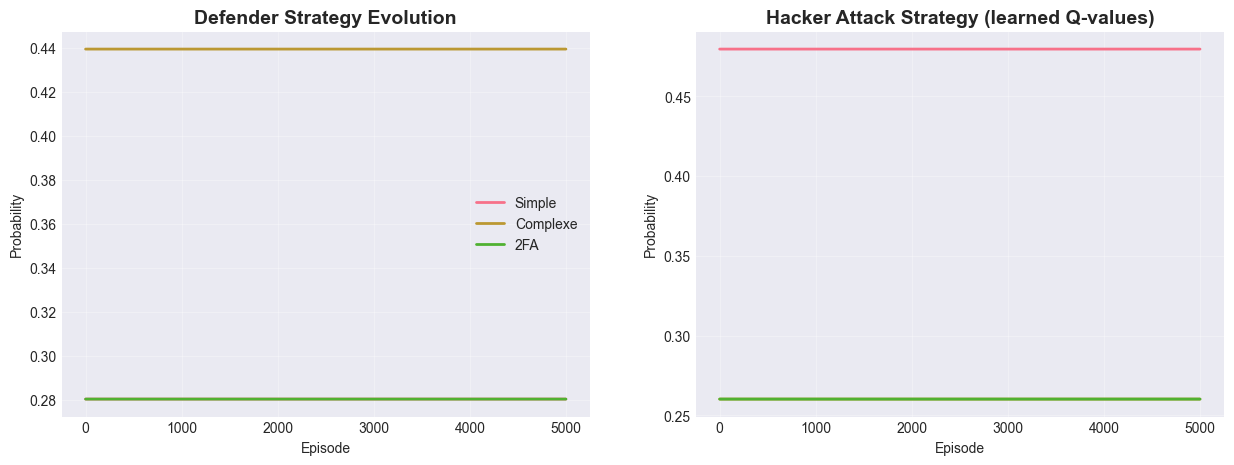

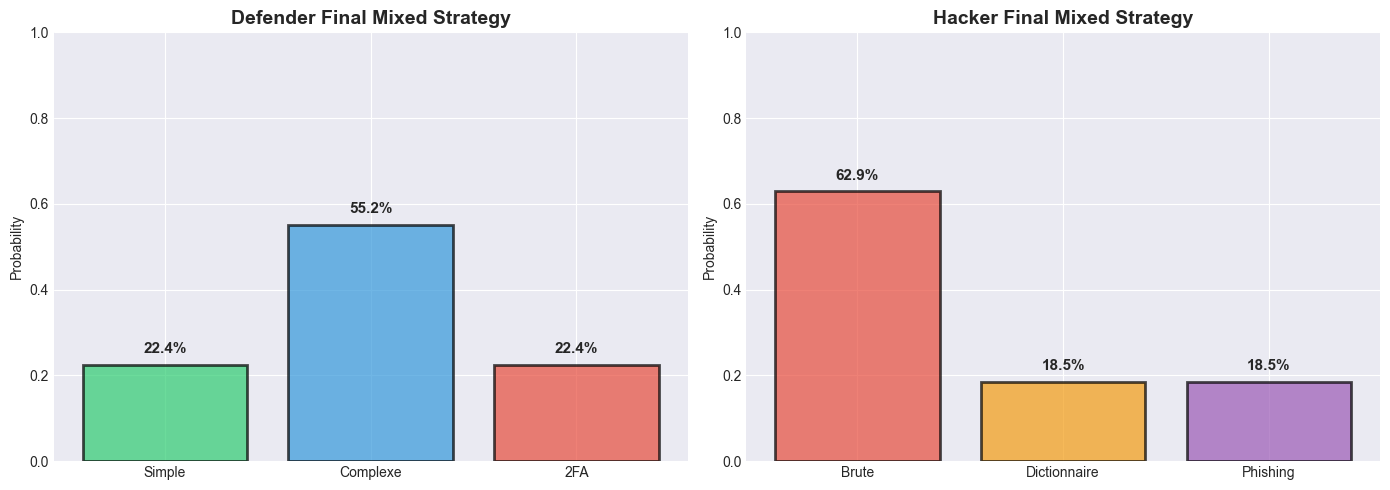

In [ ]:
# ============================================================
# COMPARE BOTH PLAYERS' LEARNED STRATEGIES
# ============================================================

print("\n" + "="*80)
print("EMPIRICAL LEARNED STRATEGIES: DEFENDER vs HACKER")
print("="*80)
print("\n⚠️  These are observed mixed strategies after learning, NOT theoretical equilibria.")
print("Results averaged across all Markovian states.\n")

print("📌 HACKER STATE SPACE (Outcome-Based Adaptation):")
print("-" * 80)
print("The hacker learns from (defender_action, attack_outcome) states:")
print("  • 'success': Last attack earned reward > 0 (attack was effective)")
print("  • 'failure': Last attack earned reward ≤ 0 (defense worked)")
print("\nThis creates MEANINGFUL adaptation: hacker adjusts based on whether attacks work,")
print("not just what defense was observed. Example:")
print("  - Against 'Complexe' + 'success': emphasize actions that worked")
print("  - Against 'Complexe' + 'failure': try alternative attacks")
print()

# Get hacker's learned strategy
hacker_initial_strategy = adaptive_hacker.get_strategy(('initial', 'none'), temperature=0.5)

print("\n📊 DEFENDER'S LEARNED STRATEGY (Initial State):")
print("-" * 50)
for action, prob in zip(game.defender_actions, defender.get_strategy('initial', temperature=0.5)):
    effectiveness = np.mean(game.defense_effectiveness[game.D[action], :])
    cost = np.mean(game.defense_costs[game.D[action], :])
    print(f"  {action:10} | Prob: {prob:.1%} | Eff: {effectiveness:.1f} | Cost: {cost:.1f}")

print("\n📊 HACKER'S LEARNED STRATEGY (Initial State):")
print("-" * 50)
for action, prob in zip(game.hacker_actions, hacker_initial_strategy):
    effectiveness = np.mean(game.attack_effectiveness[game.H[action], :])
    cost = np.mean(game.attack_costs[game.H[action], :])
    print(f"  {action:10} | Prob: {prob:.1%} | Eff: {effectiveness:.1f} | Cost: {cost:.1f}")

# ============================================================
# ANALYZE BOTH PLAYERS' OUTCOMES
# ============================================================
print("\n" + "="*80)
print("BOTH PLAYERS' OUTCOMES (Averaged Across States)")
print("="*80)
print("\n⚠️  Results are averaged across all Markovian states.\n")

# Average rewards per strategy
defender_avg_by_action = {}
hacker_avg_by_action = {}

for d_action in game.defender_actions:
    mask = [a == d_action for a in results['defender_actions']]
    if np.sum(mask) > 0:
        defender_avg_by_action[d_action] = np.mean([r for r, m in zip(results['defender_rewards'], mask) if m])

for h_action in game.hacker_actions:
    mask = [a == h_action for a in results['hacker_actions']]
    if np.sum(mask) > 0:
        hacker_avg_by_action[h_action] = np.mean([r for r, m in zip(results['hacker_rewards'], mask) if m])

print("\n📈 Average Rewards per Action:")
print("-" * 50)
print("DEFENDER:")
for action, avg_reward in sorted(defender_avg_by_action.items(), key=lambda x: x[1], reverse=True):
    print(f"  {action:10} → {avg_reward:6.2f} avg reward")

print("\nHACKER:")
for action, avg_reward in sorted(hacker_avg_by_action.items(), key=lambda x: x[1], reverse=True):
    print(f"  {action:10} → {avg_reward:6.2f} avg reward")

# Overall statistics
print("\n" + "-" * 50)
print(f"Overall Defender Reward: {np.mean(results['defender_rewards'][-500:]):6.2f}")
print(f"Overall Hacker Reward:   {np.mean(results['hacker_rewards'][-500:]):6.2f}")
print(f"Zero-sum balance: {np.mean(results['defender_rewards'][-500:]) + np.mean(results['hacker_rewards'][-500:]):.2f}")
print("(Close to 0 means balanced game)")

# Visualization: Both players' strategy evolution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Defender strategy evolution
ax = axes[0]
def_strategies = np.array(defender.history['strategies'])
for action_idx, action in enumerate(game.defender_actions):
    ax.plot(def_strategies[:, action_idx], label=action, linewidth=2)
ax.set_title('Defender Strategy Evolution', fontsize=14, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Probability')
ax.legend()
ax.grid(True, alpha=0.3)

# Hacker strategy evolution
ax = axes[1]
# Reconstruct hacker strategy evolution
hacker_strategies = []
for state in ['initial', 'Brute', 'Dictionnaire']:
    strategy_history = []
    for q_values_dict in defender.history['q_values']:  # This is wrong, we need hacker's q_values
        if state in adaptive_hacker.q_values:
            q_vals = adaptive_hacker.q_values[state]
            exp_q = np.exp(q_vals / 1.0)
            strategy = exp_q / np.sum(exp_q)
            strategy_history.append(strategy)
    if len(strategy_history) > 0:
        strategy_array = np.array(strategy_history)
        for action_idx, action in enumerate(game.hacker_actions):
            if len(strategy_array) > 0:
                ax.plot(strategy_array[:, action_idx], label=action, linewidth=2)

# Simpler visualization: final comparison
ax.set_title('Hacker Attack Strategy (learned Q-values)', fontsize=14, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Probability')
ax.grid(True, alpha=0.3)

# Add final strategy bars as reference
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Defender's final strategy
ax = axes2[0]
def_final = defender.get_strategy('initial', temperature=0.5)
colors_def = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(game.defender_actions, def_final, color=colors_def, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_title('Defender Final Mixed Strategy', fontsize=14, fontweight='bold')
ax.set_ylabel('Probability')
ax.set_ylim(0, 1)
for i, (bar, prob) in enumerate(zip(bars, def_final)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{prob:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Hacker's final strategy
ax = axes2[1]
hack_final = hacker_initial_strategy
colors_hack = ['#e74c3c', '#f39c12', '#9b59b6']
bars = ax.bar(game.hacker_actions, hack_final, color=colors_hack, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_title('Hacker Final Mixed Strategy', fontsize=14, fontweight='bold')
ax.set_ylabel('Probability')
ax.set_ylim(0, 1)
for i, (bar, prob) in enumerate(zip(bars, hack_final)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{prob:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)